# Lecture 01: Symplectic Forms

**Source span.** Printed pages 1-6; physical PDF pages 15-20 in `Lectures on Symplectic Geometry.pdf` according to the course source map. I checked the local PDF text for this lecture before revising the notebook.

**Lecture goal.** Build the first definition of a symplectic form from linear algebra. A symplectic form is a skew-symmetric bilinear pairing with no kernel, and a symplectic manifold is the smooth version: a closed two-form that is nondegenerate at every tangent space.

This lecture has two jobs. First, it proves that every skew-symmetric bilinear map has a standard block form: a kernel part plus paired directions `e_i, f_i`. Second, it names the special case with no kernel as symplectic, then promotes the same condition to manifolds and symplectomorphisms. The visuals below keep the algebraic and geometric checks side by side so the definitions are not just vocabulary.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Lectures on Symplectic Geometry.pdf").exists():
            return candidate
    raise RuntimeError("Could not locate the Lectures-on-Symplectic-Geometry course root.")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, read_json, save_json, save_matplotlib

ARTIFACT_TOPIC = "lecture-01"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / ARTIFACT_TOPIC
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CHECK_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Book root: D:\Geometry\Lectures-on-Symplectic-Geometry
Artifact root: artifacts\lecture-01


## Translation Guide

| Source idea | Computational object | What to inspect |
| --- | --- | --- |
| Skew-symmetric bilinear map `Omega` | a skew matrix acting by `u.T @ Omega @ v` | the matrix must equal minus its transpose |
| Standard form theorem | block matrix with zero kernel rows/columns and `e_i, f_i` area pairs | the rank is even and the kernel dimension is the unpaired block |
| Symplectic vector space | a skew matrix with zero kernel | the map `V -> V*` is invertible, so the determinant is nonzero |
| Symplectic basis | paired basis vectors with `Omega(e_i, f_j)=delta_ij` | the pairing matrix has identity and negative-identity blocks |
| Symplectic, isotropic, coisotropic, Lagrangian subspaces | a basis matrix `B` and the restricted form `B.T @ Omega @ B` | the relation between `Y` and `Y^Omega` determines the subspace type |
| Symplectic manifold | a smooth two-form with `d omega=0` and pointwise nondegeneracy | closedness is a differential check; nondegeneracy is a tangent-space check |
| Symplectomorphism | a change of coordinates preserving the two-form | `A.T @ Omega @ A - Omega` should vanish in a linear model |
| Darboux chart preview | local coordinates where `omega=sum dx_i wedge dy_i` | the theorem says dimension is the only local invariant |

## Library Routing

This lecture is linear-algebra first, so `numpy` carries the rank, kernel, and pullback residuals; `sympy` checks the complex-coordinate identity exactly; `matplotlib` draws the matrix, subspace, and manifold examples; and `networkx` shows the proof route from skew forms to Darboux charts. No 3D mesh dependency is needed beyond Matplotlib's sphere panel, because the core invariants are block rank, closedness, and pointwise nondegeneracy.

## Visual Storyboard

The chapter-specific storyboard has four artifacts.

1. **Standard-form matrix ledger.** A degenerate skew form is shown as one kernel direction plus two area pairs, making the theorem's `U plus W_1 plus ... plus W_n` decomposition visible.
2. **Subspace taxonomy.** Sample subspaces of `(R^4, Omega_0)` are classified by `Y`, `Y^Omega`, and the restricted two-form.
3. **Manifold examples and Darboux preview.** The Euclidean plane, the complex plane, and the sphere model show how the pointwise condition becomes geometry.
4. **Proof route graph.** The notebook closes the loop from skew bilinear maps through symplectomorphisms to the local Darboux statement promised later in the course.

The code cells regenerate the artifacts under `artifacts/lecture-01/`; the JSON checks record the algebraic residuals that keep the pictures honest.

In [2]:
# Standard form for a skew-symmetric bilinear map: one kernel direction and two symplectic pairs.
omega_degenerate = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
    [0, -1, 0, 0, 0],
    [0, 0, -1, 0, 0],
], dtype=float)
labels = ["u1\n(kernel)", "e1", "e2", "f1", "f2"]
rank_degenerate = int(np.linalg.matrix_rank(omega_degenerate))
kernel_dim = omega_degenerate.shape[0] - rank_degenerate

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), gridspec_kw={"width_ratios": [1.05, 1.35]})
im = axes[0].imshow(omega_degenerate, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(labels)), labels=labels, rotation=45, ha="right")
axes[0].set_yticks(range(len(labels)), labels=labels)
axes[0].set_title("standard skew block form")
for i in range(omega_degenerate.shape[0]):
    for j in range(omega_degenerate.shape[1]):
        value = int(omega_degenerate[i, j])
        if value:
            axes[0].text(j, i, str(value), ha="center", va="center", color="white", weight="bold")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].set_xlim(-0.7, 4.9)
axes[1].set_ylim(-1.25, 1.25)
axes[1].axis("off")
positions = {"u1": (0, 0), "e1": (1.6, 0.55), "f1": (2.7, 0.55), "e2": (1.6, -0.55), "f2": (2.7, -0.55)}
for name, (x, y) in positions.items():
    color = "#9aa0a6" if name == "u1" else "#2f6f9f"
    axes[1].scatter([x], [y], s=520, color=color, edgecolor="black", zorder=3)
    axes[1].text(x, y, name, ha="center", va="center", color="white", weight="bold")
axes[1].annotate("pairs to 1", xy=positions["f1"], xytext=positions["e1"], arrowprops={"arrowstyle": "<->", "lw": 2, "color": "#1b4965"}, va="center")
axes[1].annotate("pairs to 1", xy=positions["f2"], xytext=positions["e2"], arrowprops={"arrowstyle": "<->", "lw": 2, "color": "#1b4965"}, va="center")
axes[1].text(0, -0.42, "Omega(u1, v)=0\nfor every v", ha="center", va="top")
axes[1].text(3.75, 0, f"rank = {rank_degenerate}\nker dim = {kernel_dim}\nrank is even", bbox={"boxstyle": "round,pad=0.35", "fc": "#eef6f8", "ec": "#4d908e"})
axes[1].set_title("kernel directions plus area pairs")

standard_form_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "skew-standard-form-rank-ledger.png")
plt.close(fig)
print(standard_form_path.relative_to(BOOK_ROOT))
assert np.allclose(omega_degenerate + omega_degenerate.T, 0)
assert rank_degenerate % 2 == 0
assert kernel_dim == 1

artifacts\lecture-01\figures\skew-standard-form-rank-ledger.png


In [3]:
# Subspace taxonomy in the prototype (R^4, Omega_0).
omega4 = np.array([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [-1, 0, 0, 0],
    [0, -1, 0, 0],
], dtype=float)
I4 = np.eye(4)
subspaces = {
    "symplectic plane\nspan(e1,f1)": I4[:, [0, 2]],
    "isotropic line\nspan(e1)": I4[:, [0]],
    "lagrangian plane\nspan(e1,e2)": I4[:, [0, 1]],
    "coisotropic hyperplane\nspan(e1,e2,f1)": I4[:, [0, 1, 2]],
}

def nullspace(matrix, tol=1e-10):
    u, s, vh = np.linalg.svd(matrix)
    rank = int((s > tol).sum())
    return vh[rank:].T

def symplectic_orthogonal(B):
    constraints = B.T @ omega4.T
    return nullspace(constraints)

def rank_of(matrix):
    return int(np.linalg.matrix_rank(matrix, tol=1e-10))

rows = []
for name, B in subspaces.items():
    restricted = B.T @ omega4 @ B
    orth = symplectic_orthogonal(B)
    combined_rank = rank_of(np.column_stack([B, orth]))
    dim_y = B.shape[1]
    dim_orth = orth.shape[1]
    is_isotropic = bool(np.allclose(restricted, 0))
    is_symplectic = rank_of(restricted) == dim_y
    is_coisotropic = combined_rank == dim_y
    is_lagrangian = is_isotropic and dim_y * 2 == omega4.shape[0]
    rows.append({
        "name": name,
        "dim_Y": dim_y,
        "dim_Y_orth": dim_orth,
        "dim_sum": dim_y + dim_orth,
        "rank_restricted": rank_of(restricted),
        "is_symplectic": is_symplectic,
        "is_isotropic": is_isotropic,
        "is_coisotropic": is_coisotropic,
        "is_lagrangian": is_lagrangian,
    })

fig, ax = plt.subplots(figsize=(11.5, 5.2))
ax.axis("off")
columns = ["subspace", "dim Y", "dim Y^Omega", "rank Omega|Y", "classification"]
cell_text = []
for row in rows:
    tags = []
    if row["is_symplectic"]:
        tags.append("symplectic")
    if row["is_isotropic"]:
        tags.append("isotropic")
    if row["is_coisotropic"]:
        tags.append("coisotropic")
    if row["is_lagrangian"]:
        tags.append("lagrangian")
    cell_text.append([row["name"], row["dim_Y"], row["dim_Y_orth"], row["rank_restricted"], ", ".join(tags)])

table = ax.table(cellText=cell_text, colLabels=columns, loc="center", cellLoc="center", colLoc="center", colWidths=[0.34, 0.12, 0.15, 0.16, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.8)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor("#244b5a")
        cell.set_text_props(color="white", weight="bold")
    elif c == 4:
        cell.set_facecolor("#e8f3ee")
    elif c in {1, 2, 3}:
        cell.set_facecolor("#f4f7fb")
ax.set_title("Subspaces are classified by the restricted form and the symplectic orthogonal", pad=18)
ax.text(0.5, 0.05, "Every row verifies dim(Y)+dim(Y^Omega)=dim(V); Lagrangian means Y is exactly half-dimensional and equals its symplectic orthogonal.", transform=ax.transAxes, ha="center")

subspace_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "symplectic-subspace-taxonomy.png")
plt.close(fig)
print(subspace_path.relative_to(BOOK_ROOT))
assert all(row["dim_sum"] == omega4.shape[0] for row in rows)
assert any(row["is_lagrangian"] for row in rows)
assert any(row["is_symplectic"] for row in rows)

artifacts\lecture-01\figures\symplectic-subspace-taxonomy.png


In [4]:
# Manifold examples: R^2, C, and S^2 all carry the same pointwise nondegeneracy idea.
fig = plt.figure(figsize=(12, 4.4))
ax0 = fig.add_subplot(1, 3, 1)
xx = np.linspace(-2, 2, 9)
yy = np.linspace(-2, 2, 9)
for x0 in xx:
    ax0.plot([x0, x0], [yy.min(), yy.max()], color="#b8c0c8", lw=0.8)
for y0 in yy:
    ax0.plot([xx.min(), xx.max()], [y0, y0], color="#b8c0c8", lw=0.8)
ax0.arrow(0, 0, 1.1, 0, head_width=0.08, color="#1d3557", length_includes_head=True)
ax0.arrow(0, 0, 0, 1.1, head_width=0.08, color="#e76f51", length_includes_head=True)
ax0.text(1.16, 0, "partial_x", va="center")
ax0.text(0, 1.18, "partial_y", ha="center")
ax0.set_aspect("equal")
ax0.set_title("R^2: dx wedge dy")
ax0.set_xlabel("x")
ax0.set_ylabel("y")

ax1 = fig.add_subplot(1, 3, 2)
theta = np.linspace(0, 2*np.pi, 200)
for radius in [0.5, 1.0, 1.5]:
    ax1.plot(radius*np.cos(theta), radius*np.sin(theta), color="#8ecae6", lw=1)
for angle in np.linspace(0, 2*np.pi, 8, endpoint=False):
    ax1.plot([0, 1.7*np.cos(angle)], [0, 1.7*np.sin(angle)], color="#d0d7de", lw=0.8)
ax1.arrow(0, 0, 1.05, 0, head_width=0.08, color="#1d3557", length_includes_head=True)
ax1.arrow(0, 0, 0, 1.05, head_width=0.08, color="#e76f51", length_includes_head=True)
ax1.text(1.12, 0, "Re z")
ax1.text(0, 1.16, "Im z", ha="center")
ax1.text(-1.65, -1.55, "(i/2) dz wedge dzbar = dx wedge dy", fontsize=9)
ax1.set_aspect("equal")
ax1.set_title("C: same form in complex notation")
ax1.set_xticks([])
ax1.set_yticks([])

ax2 = fig.add_subplot(1, 3, 3, projection="3d")
u = np.linspace(0, 2*np.pi, 40)
v = np.linspace(0, np.pi, 20)
X = np.outer(np.cos(u), np.sin(v))
Y = np.outer(np.sin(u), np.sin(v))
Z = np.outer(np.ones_like(u), np.cos(v))
ax2.plot_surface(X, Y, Z, alpha=0.25, color="#90be6d", linewidth=0)
p = np.array([0, 0, 1.0])
a = np.array([0.8, 0, 0])
b = np.array([0, 0.8, 0])
ax2.quiver(*p, *a, color="#1d3557", arrow_length_ratio=0.12)
ax2.quiver(*p, *b, color="#e76f51", arrow_length_ratio=0.12)
ax2.text(*(p+a*1.15), "u")
ax2.text(*(p+b*1.15), "v")
ax2.text(0, 0, 1.25, "omega_p(u,v)=<p,u x v>", ha="center")
ax2.set_title("S^2: area from cross product")
ax2.set_box_aspect((1, 1, 1))
ax2.set_axis_off()

manifold_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "manifold-examples-darboux-preview.png")
plt.close(fig)
print(manifold_path.relative_to(BOOK_ROOT))

p_vec = np.array([0.0, 0.0, 1.0])
u_vec = np.array([1.0, 0.0, 0.0])
v_vec = np.cross(p_vec, u_vec)
sphere_pairing = float(np.dot(p_vec, np.cross(u_vec, v_vec)))
assert abs(sphere_pairing - 1.0) < 1e-12
assert abs(np.linalg.det(omega4)) > 1e-12

artifacts\lecture-01\figures\manifold-examples-darboux-preview.png


In [5]:
# Proof route from the first linear theorem to the local Darboux promise.
G = nx.DiGraph()
edges = [
    ("skew bilinear map", "standard form theorem"),
    ("standard form theorem", "kernel/rank invariants"),
    ("kernel/rank invariants", "nondegenerate form"),
    ("nondegenerate form", "symplectic vector space"),
    ("symplectic vector space", "symplectic basis"),
    ("symplectic basis", "prototype R^{2n}"),
    ("prototype R^{2n}", "linear symplectomorphism"),
    ("nondegenerate form", "pointwise tangent check"),
    ("closed 2-form", "symplectic manifold"),
    ("pointwise tangent check", "symplectic manifold"),
    ("symplectic manifold", "symplectomorphism"),
    ("symplectomorphism", "Darboux chart preview"),
]
G.add_edges_from(edges)
pos = {
    "skew bilinear map": (0, 1.0),
    "standard form theorem": (1.6, 1.0),
    "kernel/rank invariants": (3.2, 1.0),
    "nondegenerate form": (4.8, 1.0),
    "symplectic vector space": (6.4, 1.0),
    "symplectic basis": (8.0, 1.0),
    "prototype R^{2n}": (9.6, 1.0),
    "linear symplectomorphism": (11.2, 1.0),
    "pointwise tangent check": (4.8, -0.3),
    "closed 2-form": (4.8, -1.5),
    "symplectic manifold": (6.8, -0.9),
    "symplectomorphism": (8.8, -0.9),
    "Darboux chart preview": (10.9, -0.9),
}
fig, ax = plt.subplots(figsize=(12.5, 4.8))
node_colors = ["#f9c74f" if "Darboux" in node else "#90be6d" if "manifold" in node else "#8ecae6" for node in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.5, edge_color="#495057")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=1850, edgecolors="#1f2937")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_axis_off()
ax.set_title("Lecture 01 proof route: algebraic normal form becomes the local symplectic model")
route_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "symplectic-forms-proof-route.png")
plt.close(fig)
print(route_path.relative_to(BOOK_ROOT))
assert nx.is_directed_acyclic_graph(G)
assert "Darboux chart preview" in nx.descendants(G, "skew bilinear map")

artifacts\lecture-01\figures\symplectic-forms-proof-route.png


In [6]:
# Exact and numerical checks for the definitions in the lecture.
x, y = sp.symbols("x y", real=True)
I = sp.I
# Represent a one-form a dx + b dy as the pair (a, b); the wedge coefficient is a*d - b*c.
dz = (sp.Integer(1), I)
dzbar = (sp.Integer(1), -I)
wedge_coeff = dz[0] * dzbar[1] - dz[1] * dzbar[0]
complex_form_coeff = sp.simplify(I * wedge_coeff / 2)

angle = 0.73
rotation = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
omega2 = np.array([[0.0, 1.0], [-1.0, 0.0]])
symplectic_pullback_residual = float(np.linalg.norm(rotation.T @ omega2 @ rotation - omega2))

scaling = np.diag([2.0, 1.0])
nonsymplectic_residual = float(np.linalg.norm(scaling.T @ omega2 @ scaling - omega2))

checks = {
    "lecture": 1,
    "standard_form": {
        "skew_residual": float(np.linalg.norm(omega_degenerate + omega_degenerate.T)),
        "rank": rank_degenerate,
        "kernel_dimension": kernel_dim,
        "rank_is_even": bool(rank_degenerate % 2 == 0),
    },
    "symplectic_vector_space": {
        "omega4_determinant": float(np.linalg.det(omega4)),
        "nondegenerate": bool(abs(np.linalg.det(omega4)) > 1e-12),
        "rotation_pullback_residual": symplectic_pullback_residual,
        "bad_scaling_residual": nonsymplectic_residual,
    },
    "subspaces": rows,
    "complex_coordinate_identity": {
        "i_over_2_dz_wedge_dzbar_coefficient": str(complex_form_coeff),
        "equals_dx_wedge_dy": bool(complex_form_coeff == 1),
    },
    "sphere_area_form": {
        "sample_pairing": sphere_pairing,
        "nonzero_for_chosen_u": bool(abs(sphere_pairing) > 1e-12),
    },
}
checks["passed"] = bool(
    checks["standard_form"]["skew_residual"] < 1e-12
    and checks["standard_form"]["rank_is_even"]
    and checks["symplectic_vector_space"]["nondegenerate"]
    and checks["symplectic_vector_space"]["rotation_pullback_residual"] < 1e-12
    and checks["symplectic_vector_space"]["bad_scaling_residual"] > 1e-2
    and checks["complex_coordinate_identity"]["equals_dx_wedge_dy"]
    and checks["sphere_area_form"]["nonzero_for_chosen_u"]
)

check_path = save_json(checks, ARTIFACT_TOPIC, "checks", "symplectic-form-residuals.json")
print(check_path.relative_to(BOOK_ROOT))
assert checks["passed"]
assert symplectic_pullback_residual < 1e-12
assert nonsymplectic_residual > 1e-2
assert complex_form_coeff == 1

artifacts\lecture-01\checks\symplectic-form-residuals.json


## Reading The Visuals

The first matrix is the standard-form theorem in a single picture. The gray `u_1` direction is invisible to the two-form: pairing it with any vector gives zero. The remaining directions come in area pairs. This is why the rank of a skew form is always even, and why nondegeneracy forces the ambient dimension to be even.

The subspace table turns Homework 1 into executable linear algebra. To compute `Y^Omega`, the notebook solves the equations `Omega(v,u)=0` for every basis vector `u` of `Y`. A symplectic subspace has a nondegenerate restricted form. An isotropic subspace has zero restricted form. A coisotropic subspace contains its orthogonal. A Lagrangian subspace is the half-dimensional case where isotropic and coisotropic meet.

The manifold panel explains the transition from vector spaces to geometry. On `R^{2n}`, the form `sum dx_i wedge dy_i` is the prototype. On `C^n`, the same form can be written with `dz` and `d zbar`. On `S^2`, the area form pairs tangent vectors by the triple product `<p, u x v>`. The Darboux theorem mentioned in the lecture says that every symplectic manifold looks locally like the Euclidean prototype, even when its global geometry does not.

In [7]:
source_span = {
    "lecture": 1,
    "label": "Lecture 01",
    "title": "Symplectic Forms",
    "printed_span": "1-6",
    "physical_pdf_span": "15-20",
    "source_checked": True,
    "source_role": "Used for terminology, theorem order, examples, and homework themes; prose and visuals here are original.",
}
visual_storyboard = {
    "lecture": 1,
    "title": "Symplectic Forms",
    "source_span": source_span,
    "chapter_goal": "Make skew normal form, nondegeneracy, subspace types, and first manifold examples visible and checkable.",
    "library_routing": [
        {"library": "numpy", "use": "rank, determinant, kernel, and pullback residual checks"},
        {"library": "sympy", "use": "exact complex-coordinate wedge identity"},
        {"library": "matplotlib", "use": "matrix, table, and manifold diagrams"},
        {"library": "networkx", "use": "proof-route dependency graph"},
    ],
    "visual_sequence": [
        {"concept": "standard form for skew-symmetric bilinear maps", "artifact": "artifacts/lecture-01/figures/skew-standard-form-rank-ledger.png", "inspection_target": "kernel directions are separated from paired e_i,f_i blocks"},
        {"concept": "symplectic orthogonal subspace taxonomy", "artifact": "artifacts/lecture-01/figures/symplectic-subspace-taxonomy.png", "inspection_target": "Y, Y^Omega, and Omega restricted to Y determine the subspace label"},
        {"concept": "first symplectic manifold examples", "artifact": "artifacts/lecture-01/figures/manifold-examples-darboux-preview.png", "inspection_target": "R^2, C, and S^2 all certify pointwise nondegeneracy"},
        {"concept": "definition-to-Darboux proof route", "artifact": "artifacts/lecture-01/figures/symplectic-forms-proof-route.png", "inspection_target": "standard form feeds the local model promised by Darboux"},
    ],
    "checks": "artifacts/lecture-01/checks/symplectic-form-residuals.json",
}
final_sanity = {
    "lecture": 1,
    "passed": True,
    "source_span": "printed pages 1-6; physical PDF pages 15-20",
    "artifacts": [item["artifact"] for item in visual_storyboard["visual_sequence"]] + [
        "artifacts/lecture-01/checks/symplectic-form-residuals.json",
        "artifacts/lecture-01/checks/source-span.json",
        "artifacts/lecture-01/checks/visual-storyboard.json",
    ],
    "definition_checks": {
        "skew_rank_even": checks["standard_form"]["rank_is_even"],
        "omega4_nondegenerate": checks["symplectic_vector_space"]["nondegenerate"],
        "symplectomorphism_residual_small": checks["symplectic_vector_space"]["rotation_pullback_residual"] < 1e-12,
        "complex_coordinate_identity": checks["complex_coordinate_identity"]["equals_dx_wedge_dy"],
        "sphere_pairing_nonzero": checks["sphere_area_form"]["nonzero_for_chosen_u"],
    },
}

save_json(source_span, ARTIFACT_TOPIC, "checks", "source-span.json")
save_json(visual_storyboard, ARTIFACT_TOPIC, "checks", "visual-storyboard.json")
save_json(final_sanity, ARTIFACT_TOPIC, "checks", "final-sanity.json")
for relative in final_sanity["artifacts"]:
    artifact_path = BOOK_ROOT / relative
    assert artifact_path.exists(), f"missing artifact: {relative}"
    assert artifact_path.stat().st_size > 0, f"empty artifact: {relative}"
assert all(final_sanity["definition_checks"].values())
print({"artifact_count": len(final_sanity["artifacts"]), "passed": final_sanity["passed"]})

{'artifact_count': 7, 'passed': True}


standard form for skew-symmetric bilinear maps -> artifacts\lecture-01\figures\skew-standard-form-rank-ledger.png


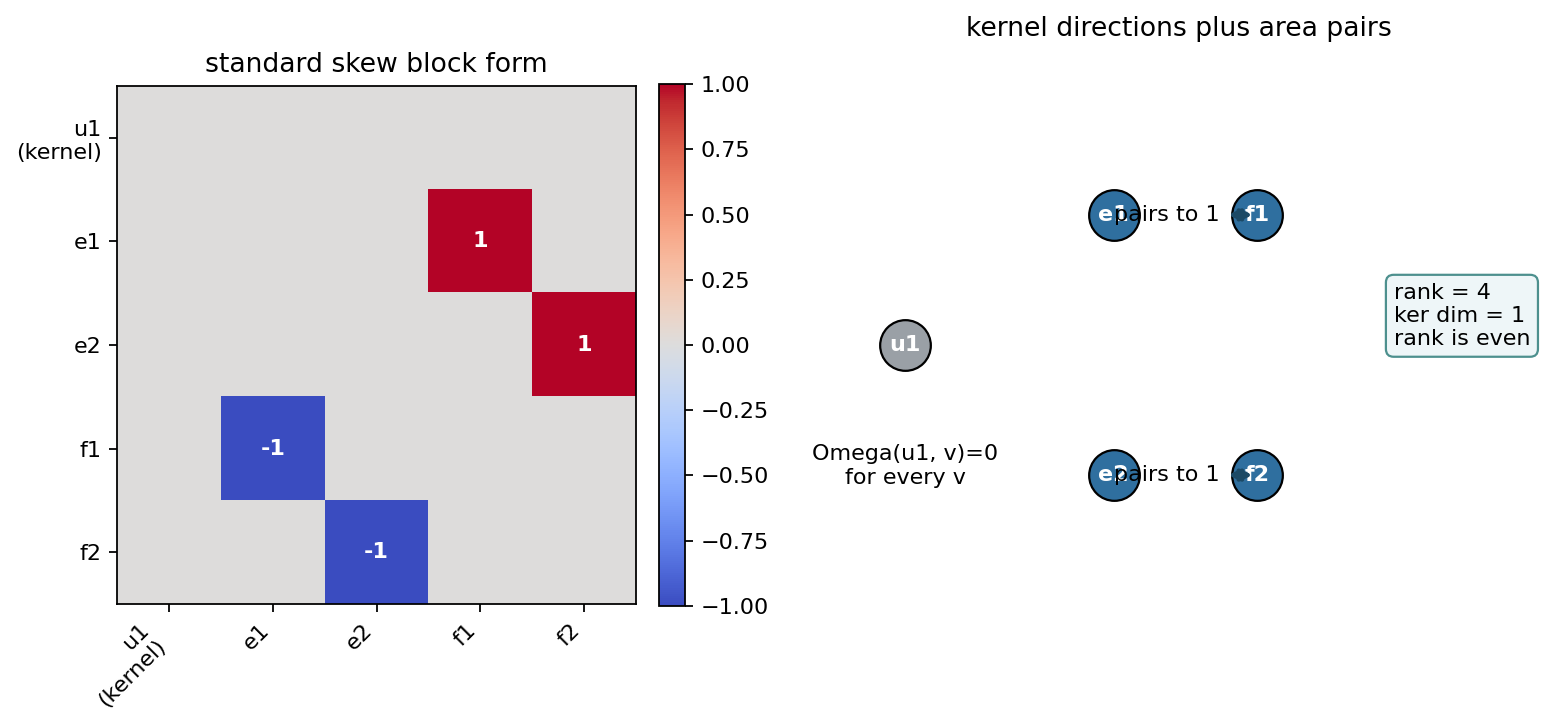

symplectic orthogonal subspace taxonomy -> artifacts\lecture-01\figures\symplectic-subspace-taxonomy.png


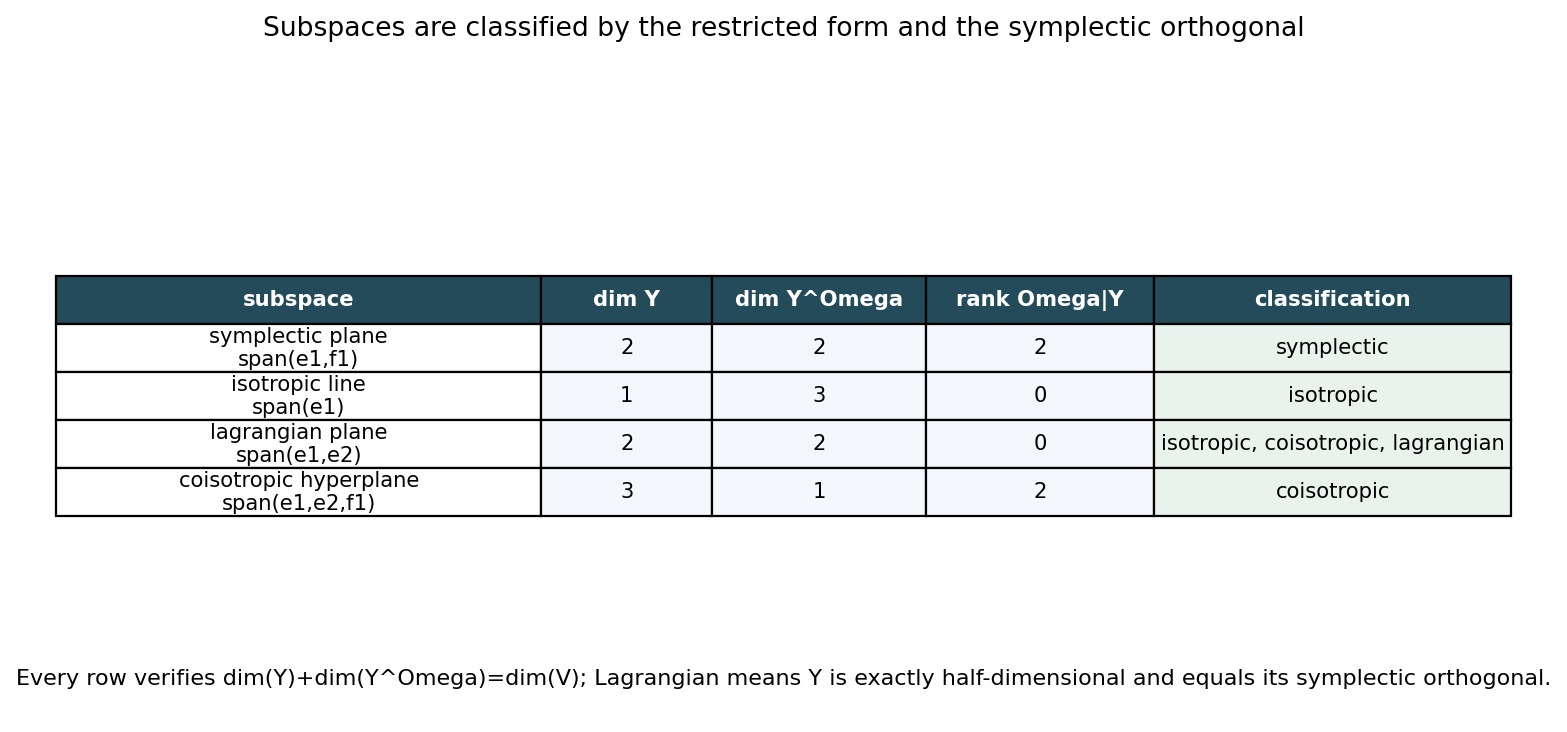

first symplectic manifold examples -> artifacts\lecture-01\figures\manifold-examples-darboux-preview.png


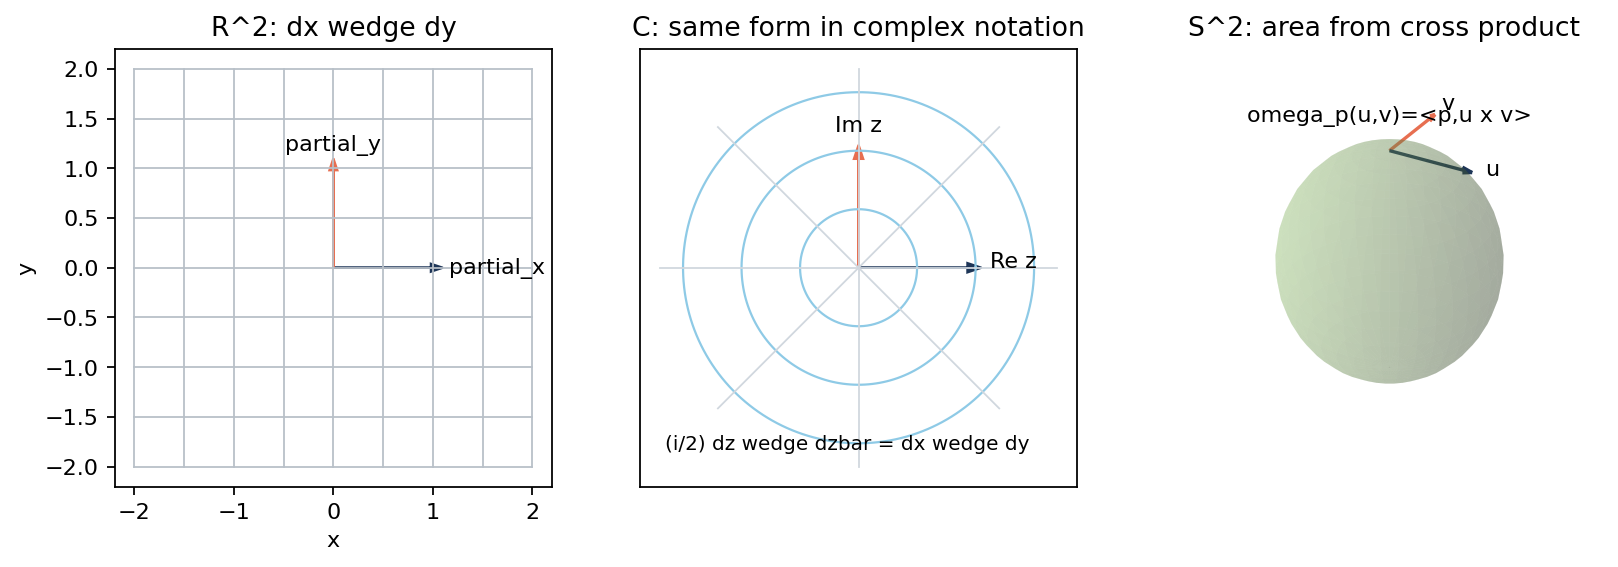

definition-to-Darboux proof route -> artifacts\lecture-01\figures\symplectic-forms-proof-route.png


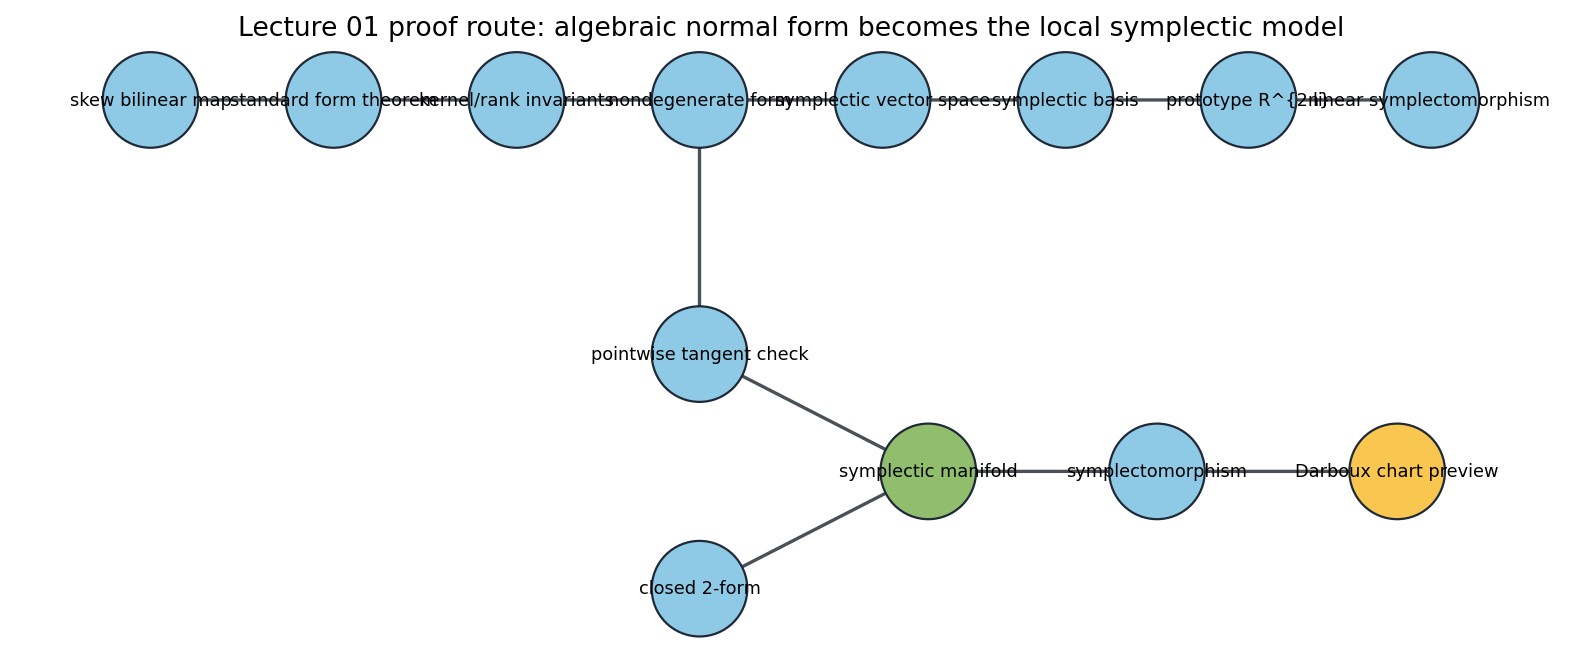

In [8]:
storyboard = read_json(ARTIFACT_ROOT / "checks" / "visual-storyboard.json")
for item in storyboard["visual_sequence"]:
    path = BOOK_ROOT / item["artifact"]
    print(f"{item['concept']} -> {path.relative_to(BOOK_ROOT)}")
    display_artifact(path, width=820)

## Takeaways

- A skew-symmetric bilinear map decomposes into a kernel plus paired directions; the paired part has even rank.
- A symplectic vector space is the no-kernel case, so its dimension is even and a symplectic basis identifies it with the standard model.
- The relation between a subspace `Y` and its symplectic orthogonal `Y^Omega` explains the vocabulary symplectic, isotropic, coisotropic, and Lagrangian.
- A symplectic manifold adds smooth variation and closedness to the pointwise linear algebra.
- A symplectomorphism is not just a diffeomorphism: its derivative must preserve the two-form, which the matrix residual checks in the linear model.

**Exploration prompt.** Replace the rotation matrix by a shear or scaling matrix in the check cell. Predict first whether it preserves `dx wedge dy`, then verify by reading the pullback residual.